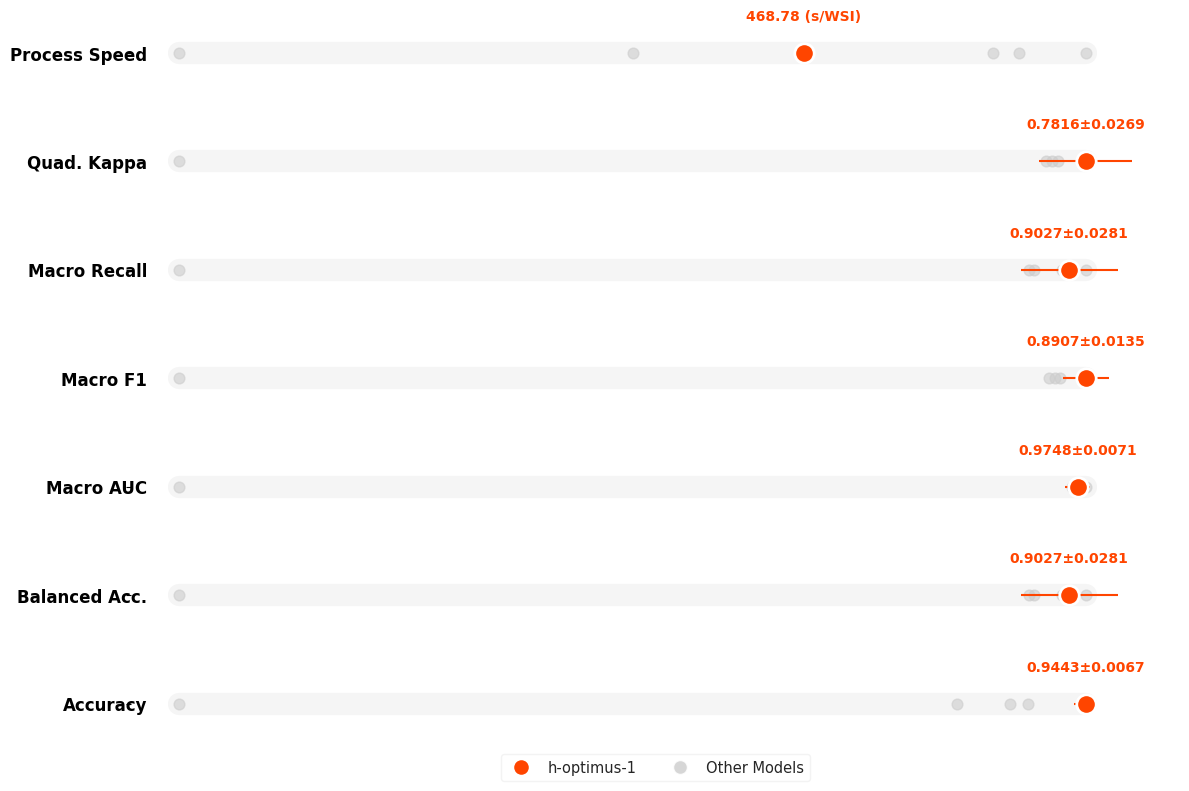

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from matplotlib.lines import Line2D

# --- 1. 数据解析函数 ---
def parse_stat(text):
    if pd.isna(text): return 0.0, 0.0
    if isinstance(text, (int, float)): return float(text), 0.0
    s = re.split('±', str(text))
    try: return float(s[0]), (float(s[1]) if len(s) > 1 else 0.0)
    except: return 0.0, 0.0

# --- 2. 参数配置 ---
df = pd.read_csv('PFM/all_metrics_summary.csv')
target = 'h-optimus-1'
perf_metrics = ['acc', 'bacc', 'macro_auc', 'macro_f1', 'macro_recall', 'quadratic_kappa']
metrics_map = {
    'acc': 'Accuracy', 'bacc': 'Balanced Acc.', 'macro_auc': 'Macro AUC',
    'macro_f1': 'Macro F1', 'macro_recall': 'Macro Recall',
    'quadratic_kappa': 'Quad. Kappa', 'time(s)': 'Process Speed'
}
colors = {'target': '#FF4500', 'others': '#CCCCCC', 'range': '#F5F5F5'}

df['val_time(s)'] = 1.0 / df['time(s)']
display_metrics = perf_metrics + ['time(s)']

fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
sns.set_style("white", {'axes.grid': False})

for i, m in enumerate(display_metrics):
    temp_df = df[['method', m]].copy()
    if m == 'time(s)':
        temp_df['val'] = 1.0 / df[m]
        temp_df['std'] = 0.0
        ascending_logic = [False, True]
    else:
        temp_df[['val', 'std']] = temp_df[m].apply(lambda x: pd.Series(parse_stat(x)))
        ascending_logic = [False, True]

    temp_df = temp_df.sort_values(['val', 'std'], ascending=ascending_logic).reset_index(drop=True)
    rank = temp_df[temp_df['method'] == target].index[0] + 1

    v_min, v_max = temp_df['val'].min(), temp_df['val'].max()
    temp_df['plot_x'] = 0.6 + (temp_df['val'] - v_min) / (v_max - v_min + 1e-9) * 0.35

    target_row = temp_df[temp_df['method'] == target].iloc[0]
    others = temp_df[temp_df['method'] != target]

    ax.hlines(y=i, xmin=temp_df['plot_x'].min(), xmax=temp_df['plot_x'].max(), color=colors['range'], linewidth=16, zorder=1, capstyle='round')
    ax.scatter(others['plot_x'], [i]*len(others), color=colors['others'], s=60, alpha=0.6, zorder=2)
    ax.errorbar(target_row['plot_x'], i, xerr=target_row['std'] / 1.5 if m != 'time(s)' else 0, 
                fmt='o', color=colors['target'], markersize=14, zorder=4, markeredgecolor='white', markeredgewidth=2)

    raw_val = df.loc[df['method'] == target, m].values[0]
    label_text = f"{raw_val} (s/WSI)" if m == 'time(s)' else f"{raw_val}"
    ax.text(target_row['plot_x'], i + 0.3, label_text, color=colors['target'], fontweight='bold', ha='center', fontsize=10)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=target, markerfacecolor=colors['target'], markersize=12, markeredgecolor='white', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', label='Other Models', markerfacecolor=colors['others'], markersize=10, alpha=0.8)
]

leg = ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.015),
                ncol=5, frameon=True, fontsize=10.5, edgecolor='#F0F0F0', facecolor='white')
leg.get_frame().set_linewidth(1.0)

ax.set_yticks(range(len(display_metrics)))
ax.set_yticklabels([metrics_map.get(m, m) for m in display_metrics], fontsize=12, fontweight='bold')
ax.tick_params(axis='y', pad=-15)
TEXT_COLOR = '#2C3E50'


sns.despine(left=True, bottom=True)
ax.set_xticks([])
plt.savefig('./result-int/pfm_benchmark.svg', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

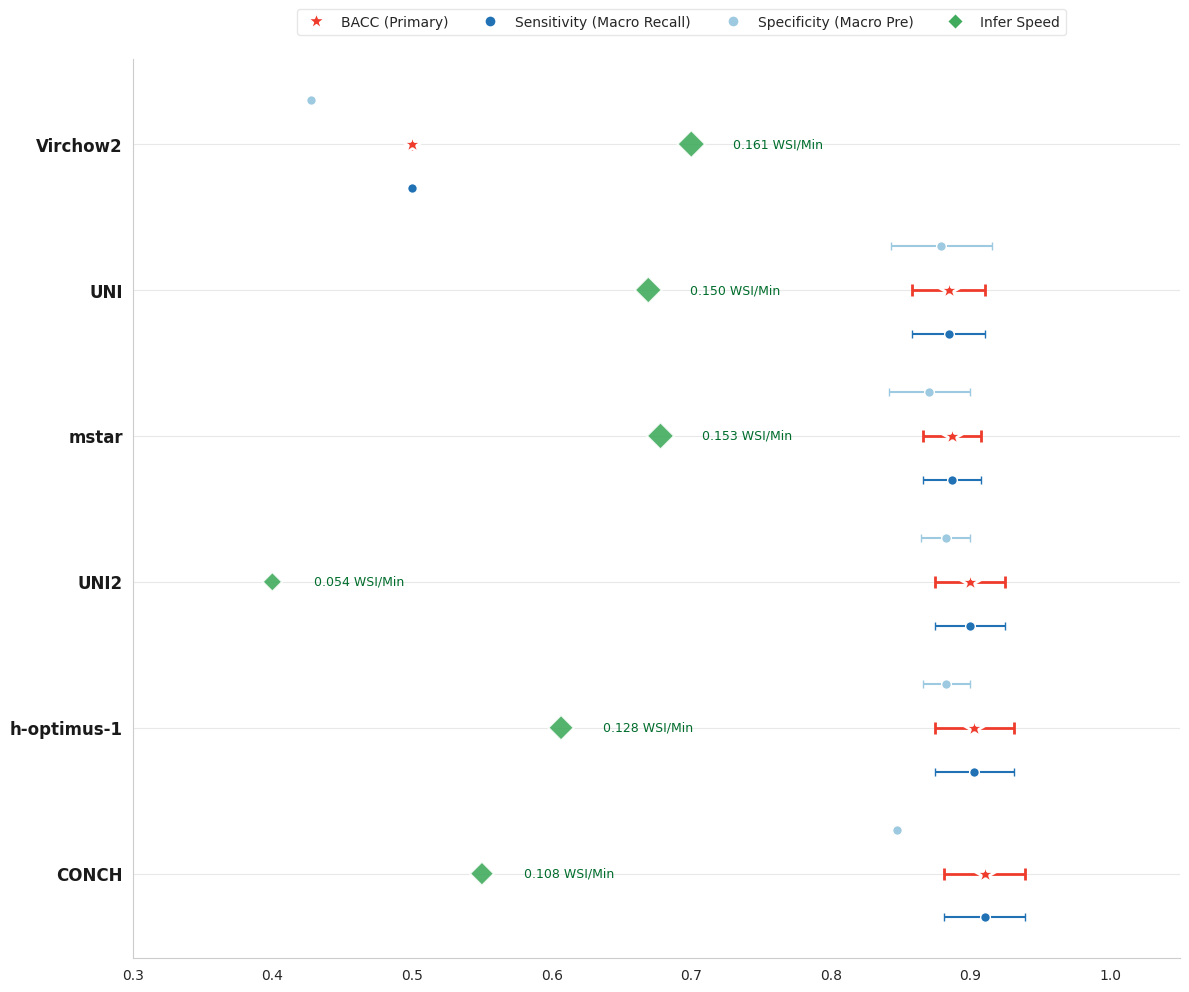

In [2]:
"""
Cleveland Dot Plot - Model Performance vs Inference Speed
=========================================================
推理速度用 x 轴位置表示（归一化到 0~1 区间），
菱形位置反映相对速度，大小也反映速度，
避免真实数据范围大（300s~1400s）导致压缩。

依赖: pip install pandas numpy matplotlib
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False


def parse_stat(text):
    if pd.isna(text):
        return 0.0, 0.0
    if isinstance(text, (int, float)):
        return float(text), 0.0
    s = re.split('±', str(text))
    try:
        return float(s[0]), (float(s[1]) if len(s) > 1 else 0.0)
    except:
        return 0.0, 0.0


# ==================== 数据配置 (修改这里) ====================
df = pd.read_csv('PFM/all_metrics_summary.csv')


# 计算速度 (WSI/s)
df['speed_wsi_s'] = 1.0 / df['time(s)']

plot_data = []
for _, row in df.iterrows():
    bacc_v, bacc_e = parse_stat(row['bacc'])
    sens_v, sens_e = parse_stat(row['macro_recall'])
    spec_v, spec_e = parse_stat(row['macro_pre'])
    plot_data.append({
        'PFM': row['method'],
        'BACC_v': bacc_v, 'BACC_e': bacc_e,
        'Sens_v': sens_v, 'Sens_e': sens_e,
        'Spec_v': spec_v, 'Spec_e': spec_e,
        'Speed': row['speed_wsi_s'],
        'Time': row['time(s)']
    })

df_plot = pd.DataFrame(plot_data)

# 按 BACC 从高到低排序 (好的模型在上)
df_plot = df_plot.sort_values('BACC_v', ascending=False).reset_index(drop=True)

# ==================== 速度归一化 (控制 x 位置 + 散点大小) ====================
# 将速度归一化到 [0.4, 0.7] 区间用于 x 轴位置显示
# 真实数据范围 300s~1400s (即 0.0007~0.0033 WSI/s) 差异很小
# 归一化后放大差异，让观众能看出快慢区别
speed_min = df_plot['Speed'].min()
speed_max = df_plot['Speed'].max()
df_plot['Speed_norm'] = (df_plot['Speed'] - speed_min) / (speed_max - speed_min)

# x 位置: 归一化速度映射到 [0.4, 0.7]
df_plot['Speed_x'] = 0.4 + df_plot['Speed_norm'] * 0.3

# 大小: 归一化速度映射到 [100, 300]
df_plot['Speed_size'] = 100 + df_plot['Speed_norm'] * 100

# ==================== 颜色配置 (可修改) ====================
COLORS = {
    'bacc': '#ef3b2c',      # 红色五角星 (主指标)
    'sens': '#2171b5',      # 蓝色圆点 (Sensitivity)
    'spec': '#9ecae1',      # 浅蓝圆点 (Specificity)
    'speed': '#41ab5d',     # 绿色菱形 (Infer Speed)
    'grid': '#e8e8e8',
    'text': '#1a1a1a'
}

# ==================== 绘图 ====================
fig, ax = plt.subplots(figsize=(12, 10))

# 纵向间距: 每个模型占 2 个单位 (拉大间距)
y_spacing = 0.5
y_pos = np.arange(len(df_plot)) * y_spacing
offset = 0.15
# 背景水平参考线
for y in y_pos:
    ax.axhline(y, color=COLORS['grid'], lw=0.8, zorder=0)

# --- A. 推理速度: 绿色菱形散点 (x 位置 + 大小都归一化) ---
# x 位置反映相对速度，大小也反映相对速度
ax.scatter(
    df_plot['Speed_x'],     # x 位置: 归一化到 [0.4, 0.7]
    y_pos,
    s=df_plot['Speed_size'],  # 大小: 归一化到 [100, 300]
    c=COLORS['speed'],
    marker='D',
    edgecolors='white',
    linewidths=1.5,
    zorder=3,
    alpha=0.9
)

# 菱形右侧标注原始速度值
for x, y, speed in zip(df_plot['Speed_x'], y_pos, df_plot['Speed']):
    ax.text(
        x + 0.03, y,
        f'{speed*60:.3f} WSI/Min',
        va='center',
        ha='left',
        fontsize=9,
        color='#006d2c',
        fontweight='500'
    )

# --- B. 辅助指标: Sensitivity (Macro Recall) ---
# 纵向偏下 0.3
ax.errorbar(
    df_plot['Sens_v'],
    y_pos - offset,
    xerr=df_plot['Sens_e'],
    fmt='o',
    color=COLORS['sens'],
    markersize=7,
    markeredgecolor='white',
    markeredgewidth=1,
    elinewidth=1.5,
    capsize=3,
    capthick=1.5,
    zorder=3
)

# --- C. 辅助指标: Specificity (Macro Pre) ---
# 纵向偏上 0.3
ax.errorbar(
    df_plot['Spec_v'],
    y_pos + offset,
    xerr=df_plot['Spec_e'],
    fmt='o',
    color=COLORS['spec'],
    markersize=7,
    markeredgecolor='white',
    markeredgewidth=1,
    elinewidth=1.5,
    capsize=3,
    capthick=1.5,
    zorder=3
)

# --- D. 主指标: BACC (大号红色五角星，居中) ---
ax.errorbar(
    df_plot['BACC_v'],
    y_pos,
    xerr=df_plot['BACC_e'],
    fmt='*',
    color=COLORS['bacc'],
    markersize=16,
    markeredgecolor='white',
    markeredgewidth=2,
    elinewidth=2,
    capsize=4,
    capthick=2,
    zorder=4
)

# ==================== 样式优化 ====================

# Y轴: 模型名称
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['PFM'], fontsize=12, fontweight='bold', color=COLORS['text'])

# X轴: 性能指标范围 (0.35 ~ 1.15，留右侧空间)
ax.set_xlim(0.3, 1.05)
ax.set_xticks(np.arange(0.3, 1.05, 0.1))
ax.set_xticklabels([f'{x:.1f}' for x in np.arange(0.3, 1.05, 0.1)], fontsize=10)

# 移除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# 图例 (上方水平排列)
legend_elements = [
    Line2D([0], [0], marker='*', color=COLORS['bacc'], linestyle='None',
           markersize=12, markeredgecolor='white', label='BACC (Primary)'),
    Line2D([0], [0], marker='o', color=COLORS['sens'], linestyle='None',
           markersize=8, markeredgecolor='white', label='Sensitivity (Macro Recall)'),
    Line2D([0], [0], marker='o', color=COLORS['spec'], linestyle='None',
           markersize=8, markeredgecolor='white', label='Specificity (Macro Pre)'),
    Line2D([0], [0], marker='D', color=COLORS['speed'], linestyle='None',
           markersize=8, markeredgecolor='white', label='Infer Speed'),
]
ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.15, 1.02),
    ncol=4,
    frameon=True,
    facecolor='white',
    edgecolor='#e0e0e0',
    fontsize=10
)

plt.tight_layout()
plt.savefig('result-int/cleveland_dot_plot.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_benchmark_radar(csv_path):
    # 1. 数据读取与均值提取
    df = pd.read_csv(csv_path)

    perf_metrics = ['acc', 'macro_recall', 'macro_f1', 'quadratic_kappa', 'macro_pre']
    time_metric = 'time(s)'

    def extract_mean(val):
        if isinstance(val, str) and '±' in val:
            return float(val.split('±')[0])
        try:
            return float(val)
        except:
            return 0.0

    plot_data = df[['method']].copy()
    for m in perf_metrics + [time_metric]:
        plot_data[m] = df[m].apply(extract_mean)

    # 2. 坐标对齐计算 (重点：通过幂运算拉开性能轴差距)
    plot_data['SPEED'] = 1.0 / plot_data[time_metric]

    norm_data = plot_data.copy()

    def amplify_diff(series, power=3.0):
        """
        通过幂运算拉大视觉差距：
        1. 归一化到 0-1
        2. 进行 N 次方处理（高分依然高，稍低的分数会显著向中心收缩）
        3. 重新映射回 0.2-1.0 以保持雷达图的美观
        """
        s_min, s_max = series.min(), series.max()
        if s_max == s_min: return np.ones_like(series)

        # 线性归一化
        linear_norm = (series - s_min) / (s_max - s_min)
        # 幂运算拉开差距，然后映射到 0.2-1.0 范围
        return np.power(linear_norm, power) * 0.5 + 0.55

    for m in perf_metrics:
        norm_data[m] = amplify_diff(plot_data[m], power=3.0)

    # SPEED 同样处理
    norm_data['SPEED'] = amplify_diff(plot_data['SPEED'], power=3.0)

    # 3. 绘图参数 (完全恢复原样)
    all_metrics = perf_metrics + ['SPEED']
    labels = [l.replace('_', ' ').upper() for l in all_metrics]
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    # 画布初始化
    fig = plt.figure(figsize=(10, 10), facecolor='white')
    ax = fig.add_subplot(111, polar=True)
    ax.set_facecolor('white')

    # 4. 配色方案 (恢复原始参数)
    colormap = plt.cm.get_cmap('Paired', len(df))
    target_method = "h-optimus-1"

    for i, (idx, row) in enumerate(norm_data.iterrows()):
        values = row[all_metrics].values.flatten().tolist()
        values += values[:1]
        name = row['method']

        if name == target_method:
            color = '#B22222'
            lw = 2
            zorder = 20
        else:
            color = colormap(i)
            lw = 1.5
            zorder = i

        ax.plot(angles, values, linewidth=lw, label=name, color=color, zorder=zorder)

    # 5. 细节美化 (完全恢复原样)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    plt.xticks(angles[:-1], labels, size=11, fontweight='bold', color='#333333')

    ax.yaxis.grid(True, color="#DDDDDD", linestyle='--', linewidth=0.5)
    ax.xaxis.grid(True, color="#DDDDDD", linewidth=0.8)

    ax.set_ylim(0, 1.1)
    ax.set_yticklabels([])

    ax.spines['polar'].set_visible(False)

    leg = plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05), frameon=True, fontsize=10, edgecolor='black', facecolor='white')
    for text in leg.get_texts():
        text.set_color("black")

    # plt.title('Foundation Models Performance: A Balanced View', size=15, pad=40, fontweight='bold', color='black')
    # plt.savefig('./result-int/pfm_benchmark.svg', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


plot_benchmark_radar('PFM/all_metrics_summary.csv')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- 1. 数据处理 ---
df = pd.read_csv('Mag/all_metrics_summary.csv')  # 改成你的实际路径

def extract_mean(val):
    if isinstance(val, str) and '±' in val:
        return float(val.split('±')[0])
    try:
        return float(val)
    except:
        return 0.0

df['macro_f1'] = df['macro_f1'].apply(extract_mean)
df['time'] = df['time(s)'].apply(extract_mean)
df['sort_val'] = df['method'].str.extract(r'(\d+)').astype(int)
df = df.sort_values('sort_val').reset_index(drop=True)

# --- 2. 颜色配置 (更协调的配色) ---
BAR_5 = '#95a5a6'
BAR_10 = '#2980b9'   # 深蓝 (高亮)
BAR_20 = '#7F8C8D'
ACC_COLOR = '#B16968'
TEXT_COLOR = '#2c3e50'

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=120, facecolor='white')

# --- 3. 柱状图 (左轴: 时间) ---
x = np.arange(len(df))
colors = [BAR_5, BAR_10, BAR_20]

ax1.bar(x, df['time'], color=colors, width=0.5, alpha=0.85, zorder=2)
ax1.set_xlabel('Magnification Level', fontsize=12, color=TEXT_COLOR, fontweight='bold')
ax1.set_ylabel('Avg. Processing Time per Slide (s)', fontsize=11, color=BAR_20)
ax1.set_xticks(x)
ax1.set_xticklabels(df['method'], fontsize=11, fontweight='600', color=TEXT_COLOR)

for spine in ['top', 'right']: ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color(BAR_20)
ax1.spines['bottom'].set_color('#bdc3c7')
ax1.tick_params(axis='y', colors=BAR_20)

# --- 4. 折线图 (右轴: 准确率) ---
ax2 = ax1.twinx()

# 放大差异: 限制y轴范围到数据附近
acc_min, acc_max = df['macro_f1'].min(), df['macro_f1'].max()
margin = (acc_max - acc_min) * 0.3
ax2.set_ylim(acc_min - margin, acc_max + margin)

ax2.plot(x, df['macro_f1'], color=ACC_COLOR, marker='o', markersize=10, linewidth=3, markerfacecolor='white', markeredgewidth=2.5, zorder=5)
ax2.set_ylabel('Macro F1 (Mean)', fontsize=11, color=ACC_COLOR)

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_color(ACC_COLOR)
ax2.tick_params(axis='y', colors=ACC_COLOR)

target_mask = df['method'].astype(str).str.contains('10')
if target_mask.any():
    idx = df.index[target_mask][0]
    ax2.annotate('Optimal Balance\n(3.7× Speedup)',
                 xy=(idx, df['macro_f1'].iloc[idx]),
                 xytext=(idx + 0.3, df['macro_f1'].iloc[idx] + margin * 0.5),
                 fontsize=9, fontweight='bold', color='white', ha='center',
                 bbox=dict(boxstyle='round,pad=0.5', fc=TEXT_COLOR, ec='none', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color=TEXT_COLOR))


legend_elements = [
    Patch(facecolor=BAR_10, alpha=0.85, label='Inference Time (s)'),
    Line2D([0], [0], color=ACC_COLOR, marker='o', markersize=8,
           markerfacecolor='white', markeredgewidth=2, label='Classification Macro F1')
]
ax1.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False, fontsize=10)

# ax1.set_title('Efficiency-Accuracy Balance', fontsize=14, fontweight='bold', pad=40, color=TEXT_COLOR)

ax1.grid(axis='y', linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
plt.savefig('./result-int/mag_tradeoff.svg', dpi=300, bbox_inches='tight')
plt.show()

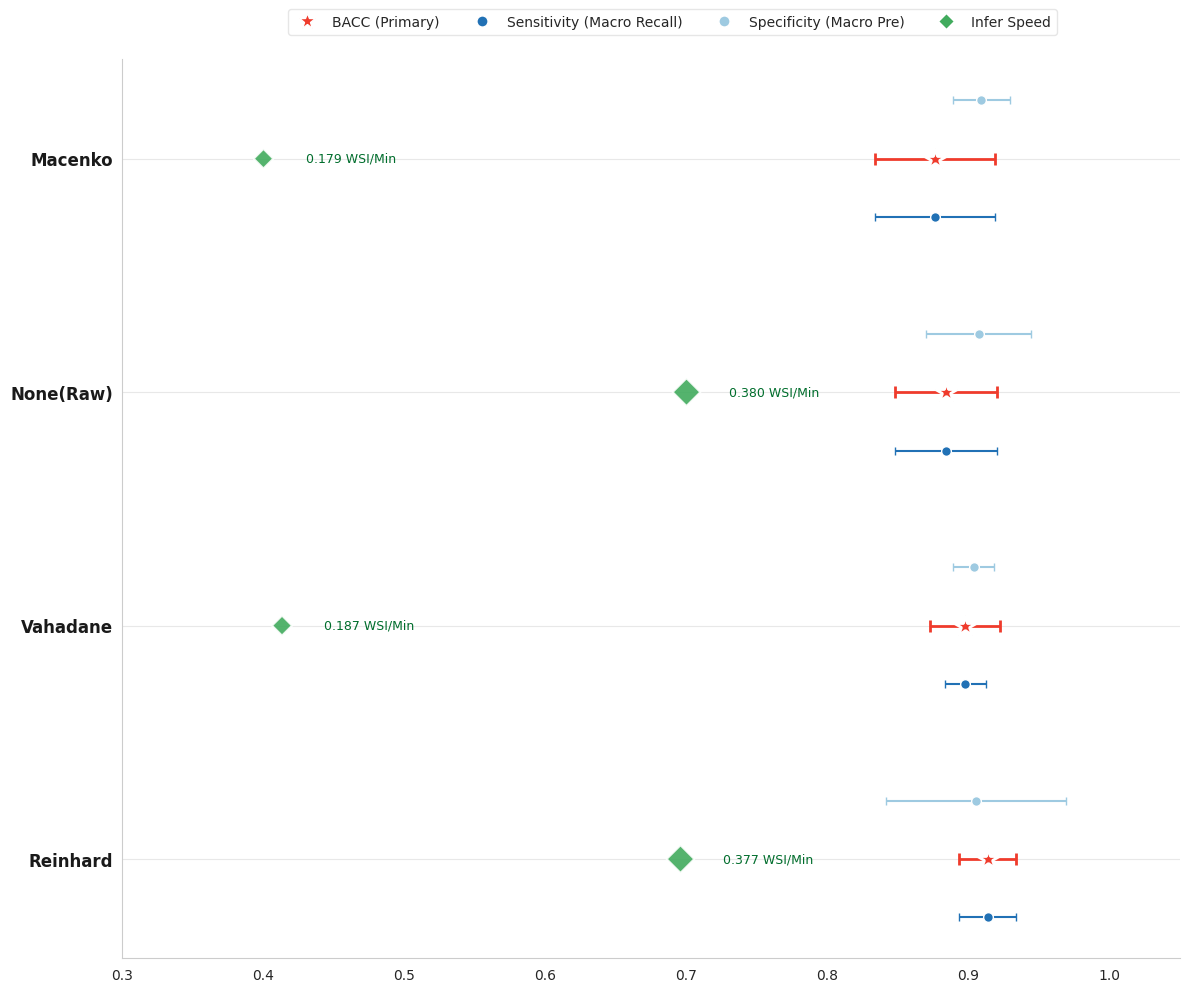

In [25]:
"""
Cleveland Dot Plot - Model Performance vs Inference Speed
=========================================================
推理速度用 x 轴位置表示（归一化到 0~1 区间），
菱形位置反映相对速度，大小也反映速度，
避免真实数据范围大（300s~1400s）导致压缩。

依赖: pip install pandas numpy matplotlib
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False


def parse_stat(text):
    if pd.isna(text):
        return 0.0, 0.0
    if isinstance(text, (int, float)):
        return float(text), 0.0
    s = re.split('±', str(text))
    try:
        return float(s[0]), (float(s[1]) if len(s) > 1 else 0.0)
    except:
        return 0.0, 0.0


# ==================== 数据配置 (修改这里) ====================
df = pd.read_csv('Stains/all_metrics_summary.csv')


# 计算速度 (WSI/s)
df['speed_wsi_s'] = 1.0 / df['time(s)']

plot_data = []
for _, row in df.iterrows():
    bacc_v, bacc_e = parse_stat(row['bacc'])
    sens_v, sens_e = parse_stat(row['macro_recall'])
    spec_v, spec_e = parse_stat(row['macro_pre'])
    plot_data.append({
        'PFM': row['method'],
        'BACC_v': bacc_v, 'BACC_e': bacc_e,
        'Sens_v': sens_v, 'Sens_e': sens_e,
        'Spec_v': spec_v, 'Spec_e': spec_e,
        'Speed': row['speed_wsi_s'],
        'Time': row['time(s)']
    })

df_plot = pd.DataFrame(plot_data)

# 按 BACC 从高到低排序 (好的模型在上)
df_plot = df_plot.sort_values('BACC_v', ascending=False).reset_index(drop=True)

# ==================== 速度归一化 (控制 x 位置 + 散点大小) ====================
# 将速度归一化到 [0.4, 0.7] 区间用于 x 轴位置显示
# 真实数据范围 300s~1400s (即 0.0007~0.0033 WSI/s) 差异很小
# 归一化后放大差异，让观众能看出快慢区别
speed_min = df_plot['Speed'].min()
speed_max = df_plot['Speed'].max()
df_plot['Speed_norm'] = (df_plot['Speed'] - speed_min) / (speed_max - speed_min)

# x 位置: 归一化速度映射到 [0.4, 0.7]
df_plot['Speed_x'] = 0.4 + df_plot['Speed_norm'] * 0.3

# 大小: 归一化速度映射到 [100, 300]
df_plot['Speed_size'] = 100 + df_plot['Speed_norm'] * 100

# ==================== 颜色配置 (可修改) ====================
COLORS = {
    'bacc': '#ef3b2c',      # 红色五角星 (主指标)
    'sens': '#2171b5',      # 蓝色圆点 (Sensitivity)
    'spec': '#9ecae1',      # 浅蓝圆点 (Specificity)
    'speed': '#41ab5d',     # 绿色菱形 (Infer Speed)
    'grid': '#e8e8e8',
    'text': '#1a1a1a'
}

# ==================== 绘图 ====================
fig, ax = plt.subplots(figsize=(12, 10))

# 纵向间距: 每个模型占 2 个单位 (拉大间距)
y_spacing = 0.2
y_pos = np.arange(len(df_plot)) * y_spacing
offset = 0.05
# 背景水平参考线
for y in y_pos:
    ax.axhline(y, color=COLORS['grid'], lw=0.8, zorder=0)

# --- A. 推理速度: 绿色菱形散点 (x 位置 + 大小都归一化) ---
# x 位置反映相对速度，大小也反映相对速度
ax.scatter(
    df_plot['Speed_x'],     # x 位置: 归一化到 [0.4, 0.7]
    y_pos,
    s=df_plot['Speed_size'],  # 大小: 归一化到 [100, 300]
    c=COLORS['speed'],
    marker='D',
    edgecolors='white',
    linewidths=1.5,
    zorder=3,
    alpha=0.9
)

# 菱形右侧标注原始速度值
for x, y, speed in zip(df_plot['Speed_x'], y_pos, df_plot['Speed']):
    ax.text(
        x + 0.03, y,
        f'{speed*60:.3f} WSI/Min',
        va='center',
        ha='left',
        fontsize=9,
        color='#006d2c',
        fontweight='500'
    )

# --- B. 辅助指标: Sensitivity (Macro Recall) ---
# 纵向偏下 0.3
ax.errorbar(
    df_plot['Sens_v'],
    y_pos - offset,
    xerr=df_plot['Sens_e'],
    fmt='o',
    color=COLORS['sens'],
    markersize=7,
    markeredgecolor='white',
    markeredgewidth=1,
    elinewidth=1.5,
    capsize=3,
    capthick=1.5,
    zorder=3
)

# --- C. 辅助指标: Specificity (Macro Pre) ---
# 纵向偏上 0.3
ax.errorbar(
    df_plot['Spec_v'],
    y_pos + offset,
    xerr=df_plot['Spec_e'],
    fmt='o',
    color=COLORS['spec'],
    markersize=7,
    markeredgecolor='white',
    markeredgewidth=1,
    elinewidth=1.5,
    capsize=3,
    capthick=1.5,
    zorder=3
)

# --- D. 主指标: BACC (大号红色五角星，居中) ---
ax.errorbar(
    df_plot['BACC_v'],
    y_pos,
    xerr=df_plot['BACC_e'],
    fmt='*',
    color=COLORS['bacc'],
    markersize=16,
    markeredgecolor='white',
    markeredgewidth=2,
    elinewidth=2,
    capsize=4,
    capthick=2,
    zorder=4
)

# ==================== 样式优化 ====================

# Y轴: 模型名称
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['PFM'], fontsize=12, fontweight='bold', color=COLORS['text'])

# X轴: 性能指标范围 (0.35 ~ 1.15，留右侧空间)
ax.set_xlim(0.3, 1.05)
ax.set_xticks(np.arange(0.3, 1.05, 0.1))
ax.set_xticklabels([f'{x:.1f}' for x in np.arange(0.3, 1.05, 0.1)], fontsize=10)

# 移除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# 图例 (上方水平排列)
legend_elements = [
    Line2D([0], [0], marker='*', color=COLORS['bacc'], linestyle='None',
           markersize=12, markeredgecolor='white', label='BACC (Primary)'),
    Line2D([0], [0], marker='o', color=COLORS['sens'], linestyle='None',
           markersize=8, markeredgecolor='white', label='Sensitivity (Macro Recall)'),
    Line2D([0], [0], marker='o', color=COLORS['spec'], linestyle='None',
           markersize=8, markeredgecolor='white', label='Specificity (Macro Pre)'),
    Line2D([0], [0], marker='D', color=COLORS['speed'], linestyle='None',
           markersize=8, markeredgecolor='white', label='Infer Speed'),
]
ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.15, 1.02),
    ncol=4,
    frameon=True,
    facecolor='white',
    edgecolor='#e0e0e0',
    fontsize=10
)

plt.tight_layout()
plt.savefig('result-int/stains.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# =========================
# 1. Load & process data
# =========================
df = pd.read_csv('Mag/all_metrics_summary.csv')

def extract_mean(val):
    if isinstance(val, str) and '±' in val:
        return float(val.split('±')[0])
    try:
        return float(val)
    except:
        return 0.0

def extract_std(val):
    if isinstance(val, str) and '±' in val:
        return float(val.split('±')[1])
    return 0.0

df['macro_f1'] = df['macro_f1'].apply(extract_mean)
df['macro_f1_std'] = df['macro_f1'].apply(extract_std)
df['time'] = df['time(s)'].apply(extract_mean)
df['time_std'] = df['time(s)'].apply(extract_std)
df['sort_val'] = df['method'].str.extract(r'(\d+)').astype(int)
df = df.sort_values('sort_val').reset_index(drop=True)

# --- 2. 颜色配置 ---
BAR_5 = '#BDC3C7'    # 浅灰
BAR_10 = '#5D6D7E'   # 深灰蓝（略强调）
BAR_20 = '#D5D8DC'   # 浅灰（比5×更浅）
ACC_COLOR = '#B16968'
TEXT_COLOR = '#2c3e50'

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=120, facecolor='white')

# --- 3. 柱状图 (左轴: 时间) ---
x = np.arange(len(df))
colors = [BAR_5, BAR_10, BAR_20]

bars = ax1.bar(x, df['time'], color=colors, width=0.5, alpha=0.85, zorder=2)
# 加误差线
ax1.errorbar(x, df['time'], yerr=df['time_std'], fmt='none', 
             ecolor='#555555', capsize=5, capthick=1.5, elinewidth=1.5, zorder=3)

ax1.set_xlabel('Magnification Level', fontsize=12, color=TEXT_COLOR, fontweight='bold')
ax1.set_ylabel('Avg. Processing Time per Slide (s)', fontsize=11, color='#555555')
ax1.set_xticks(x)
ax1.set_xticklabels(df['method'], fontsize=11, fontweight='600', color=TEXT_COLOR)

for spine in ['top', 'right']: ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color('#bdc3c7')
ax1.spines['bottom'].set_color('#bdc3c7')
ax1.tick_params(axis='y', colors='#555555')

# --- 4. 折线图 (右轴: 准确率) ---
ax2 = ax1.twinx()

acc_min, acc_max = df['macro_f1'].min(), df['macro_f1'].max()
margin = (acc_max - acc_min) * 0.3
ax2.set_ylim(acc_min - margin, acc_max + margin)

ax2.plot(x, df['macro_f1'], color=ACC_COLOR, marker='o', markersize=10, 
         linewidth=3, markerfacecolor='white', markeredgewidth=2.5, zorder=5)

# 加 error bar
ax2.errorbar(x, df['macro_f1'], yerr=df['macro_f1_std'], fmt='none',
             ecolor=ACC_COLOR, capsize=5, capthick=1.5, elinewidth=1.5, zorder=4)

ax2.set_ylabel('Macro F1 (Mean)', fontsize=11, color=ACC_COLOR)

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_color(ACC_COLOR)
ax2.tick_params(axis='y', colors=ACC_COLOR)

# --- 5. 小箭头指向 Selected ---
target_mask = df['method'].astype(str).str.contains('10')
if target_mask.any():
    idx = df.index[target_mask][0]
    ax2.annotate('Selected 10x',
                 xy=(idx, df['macro_f1'].iloc[idx]),
                 xytext=(idx + 0.35, df['macro_f1'].iloc[idx] + margin * 0.45),
                 fontsize=10, fontweight='bold', color=TEXT_COLOR, ha='center',
                 arrowprops=dict(arrowstyle='->', color=TEXT_COLOR, lw=1.5),
                 bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=TEXT_COLOR, alpha=0.9),)

legend_elements = [
    Patch(facecolor=BAR_10, alpha=0.85, label='Inference Time (s)'),
    Line2D([0], [0], color=ACC_COLOR, marker='o', markersize=8,
           markerfacecolor='white', markeredgewidth=2, label='Macro F1')
]
ax1.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False, fontsize=10)

ax1.grid(axis='y', linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
plt.savefig('./result-int/mag_tradeoff.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ========== 1. 数据解析 ==========
def extract_mean(val):
    if isinstance(val, str) and '±' in val:
        return float(val.split('±')[0])
    try: return float(val)
    except: return 0.0

# 替换为你的真实CSV路径
df = pd.read_csv('Stains/all_metrics_summary.csv')

df['acc_m'] = df['acc'].apply(extract_mean)
df['f1_m'] = df['macro_f1'].apply(extract_mean)
df['time_m'] = df['time(s)'].apply(extract_mean)

# ========== 2. 颜色配置 ==========
METHOD_COLORS = {
    'None(Raw)':   '#7F8C8D',
    'Reinhard':    '#C0392B',
    'Macenko':     '#2980B9',
    'Vahadane':    '#27AE60',
}
TEXT_COLOR = '#2C3E50'

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

# ========== 3. Optimal Zone (右下角 + 文字说明) ==========
time_mid = 240
acc_mid = 0.945

ax.axvspan(130, time_mid, ymin=0.35, ymax=1.0, color='#E8F8F5', alpha=0.5, zorder=0)
ax.axvline(x=time_mid, color='#1ABC9C', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
ax.axhline(y=acc_mid, color='#1ABC9C', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

# 标签移到右下角，加说明文字
ax.text(175, 0.9455, 'Optimal Zone\n(Fast & Accurate)', fontsize=9, fontweight='bold',
        color='#A3E4D7', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#A3E4D7', alpha=0.9))

# ========== 4. 绘制气泡 ==========
f1_min, f1_max = df['f1_m'].min(), df['f1_m'].max()

f1_norm = (df['f1_m'] - f1_min) / (f1_max - f1_min + 1e-9)
sizes = 300 + np.power(f1_norm, 0.3) * 50

colors = [METHOD_COLORS.get(m, '#B2BABB') for m in df['method']]

for i, row in df.iterrows():
    is_reinhard = 'Reinhard' in row['method']

    if is_reinhard:
        for j, (scale, alpha, lw) in enumerate([(3.0, 0.06, 8), (2.2, 0.12, 5), (1.6, 0.2, 3), (1.2, 0.3, 2)]):
            ax.scatter(row['time_m'], row['acc_m'], s=sizes.iloc[i]*scale, c='none',
                       edgecolors=METHOD_COLORS['Reinhard'], linewidth=lw, alpha=alpha, zorder=2+j)
        ax.scatter(row['time_m'], row['acc_m'], s=sizes.iloc[i],
                   c=METHOD_COLORS['Reinhard'], alpha=0.95,
                   edgecolors='white', linewidth=3, zorder=6)
    else:
        ax.scatter(row['time_m'], row['acc_m'], s=sizes.iloc[i],
                   c=colors[i], alpha=0.85, edgecolors='white', linewidth=2, zorder=4)

# ========== 5. 标签 ==========
label_offsets = {
    'None(Raw)':   (-35, -18),
    'Reinhard':    (0, 28),
    'Macenko':     (30, 15),
    'Vahadane':    (0, -25),
}

for i, row in df.iterrows():
    offset = label_offsets.get(row['method'], (0, 20))
    ax.annotate(row['method'],
                (row['time_m'], row['acc_m']),
                xytext=offset, textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold',
                color=METHOD_COLORS.get(row['method'], TEXT_COLOR))

acc_min_all = df['acc_m'].min()
acc_max_all = df['acc_m'].max()
margin = (acc_max_all - acc_min_all) * 0.12

ax.set_xlim(130, 360)
ax.set_ylim(0.941, acc_max_all + margin)

y_ticks = [0.941, 0.943, 0.945, 0.947, 0.949, round(acc_max_all + margin, 3)]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{y:.3f}' for y in y_ticks])

ax.set_xlabel('Processing Time (s)', fontsize=13, fontweight='bold', color=TEXT_COLOR)
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold', color=TEXT_COLOR)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.grid(linestyle='--', alpha=0.2, zorder=1)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D

legend_elements = []
for method, color in METHOD_COLORS.items():
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=method, markeredgecolor='white', markeredgewidth=1.5)
    )
legend_elements.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#BDC3C7', markersize=6,
           label=f'Bubble: Macro F1 ({f1_min:.2f}-{f1_max:.2f})', markeredgecolor='white', markeredgewidth=1)
)

ax.legend(handles=legend_elements, loc='lower left', frameon=True, facecolor='white',
          edgecolor='#D5DBDB', fontsize=9, bbox_to_anchor=(0.02, 0.02))

# ax.set_title('Normalization Comparison', fontsize=14, fontweight='bold', pad=20, color=TEXT_COLOR)

plt.tight_layout()
plt.savefig('./result-int/stain_bubble.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# --- 1. 数据解析函数 ---
def parse_stat(text):
    if pd.isna(text): return 0.0, 0.0
    if isinstance(text, (int, float)): return float(text), 0.0
    s = re.split('±', str(text))
    try: return float(s[0]), (float(s[1]) if len(s) > 1 else 0.0)
    except: return 0.0, 0.0

# --- 2. 参数配置 ---
df = pd.read_csv('PFM/all_metrics_summary.csv')
target = 'h-optimus-1'
perf_metrics = ['acc', 'bacc', 'macro_auc', 'macro_f1', 'macro_recall', 'quadratic_kappa']
metrics_map = {
    'acc': 'Accuracy', 'bacc': 'Balanced Acc.', 'macro_auc': 'Macro AUC',
    'macro_f1': 'Macro F1', 'macro_recall': 'Macro Recall',
    'quadratic_kappa': 'Quad. Kappa', 'time(s)': 'Inference Time'
}

# --- 3. 构建排名矩阵 ---
all_metrics = perf_metrics + ['time(s)']
norm_matrix, label_matrix = [], []
num_methods = len(df)

for m in all_metrics:
    if m == 'time(s)':
        vals = df[m].values.astype(float)
        # 时间越短排名越前
        ranks = pd.Series(vals).rank(method='min').astype(int).values
        labels = [f"{v:.1f}s\nRank #{r}" for v, r in zip(vals, ranks)]
    else:
        stats = df[m].apply(parse_stat)
        means = np.array([x[0] for x in stats])
        stds = np.array([x[1] for x in stats])
        # 排名逻辑：均值降序，标准差升序
        rank_df = pd.DataFrame({'m': means, 's': stds})
        sort_idx = rank_df.sort_values(['m', 's'], ascending=[False, True]).index
        # 还原排名到原始顺序
        final_ranks = np.zeros(num_methods, dtype=int)
        for r, idx in enumerate(sort_idx):
            final_ranks[idx] = r + 1
        ranks = final_ranks
        labels = [f"{mv:.4f}\nRank #{r}" for mv, r in zip(means, ranks)]

    # 排名映射颜色：Rank 1 为 1.0 (最深)，末名为 0.0 (最浅)
    line_norm = (num_methods - ranks).astype(float) / max(num_methods - 1, 1)
    norm_matrix.append(line_norm)
    label_matrix.append(labels)

# --- 4. 绘图 ---
plt.figure(figsize=(15, 9), dpi=100)
plot_data = np.array(norm_matrix)

ax = sns.heatmap(plot_data,
                 annot=np.array(label_matrix), fmt="", cmap="GnBu",
                 cbar=False, vmin=0, vmax=1, linewidths=2.5, linecolor='white',
                 xticklabels=df['method'].values,
                 yticklabels=[metrics_map.get(m, m) for m in all_metrics],
                 annot_kws={"fontsize": 9, "fontweight": "bold"})

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold', rotation=0)
# plt.title(f"Rank-Based Matrix: {target} vs Others", fontsize=16, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from concurrent.futures import ThreadPoolExecutor

# --- 基础配置 ---
plt.rcParams['font.family'] = 'sans-serif'
csv_path = "/NAS2/Data1/lbliao/Code-195/MIL_BASELINE/datasets/Contrast/train_val2.csv"

# --- 1. 加载并去重 CSV ---
df = pd.read_csv(csv_path)
df = df.drop_duplicates(subset=['slide_path'])

# --- 2. 定义单个文件的加载函数 ---
def load_single_feat(row):
    fpath = row['slide_path']
    label = row['label']

    if not os.path.exists(fpath):
        return None

    try:
        feat = torch.load(fpath, map_location='cpu')
        if feat.ndim > 1:
            m_feat = feat.mean(0)
            mx_feat = feat.max(0)[0]
            feat = torch.cat([m_feat, mx_feat])
        return feat.numpy().flatten(), label
    except Exception:
        return None


# --- 3. 并行加载特征 ---
features = []
labels = []

print(f"正在并行加载 {len(df)} 个特征文件...")

with ThreadPoolExecutor(max_workers=30) as executor:
    results = list(executor.map(load_single_feat, [row for _, row in df.iterrows()]))

for res in results:
    if res is not None:
        features.append(res[0])
        labels.append(res[1])

X = np.array(features)
print(f"加载完成，有效样本数: {len(X)}")


X_scaled = StandardScaler().fit_transform(X)

n_samples = len(X)
current_perp = min(50, max(1, n_samples - 1))

print(f"正在运行 t-SNE (Perplexity={current_perp})...")
tsne = TSNE(
    n_components=2,
    perplexity=current_perp,
    random_state=42,
    init='pca' if n_samples > 30 else 'random',
    n_jobs=-1
)
X_2d = tsne.fit_transform(X_scaled)

# --- 5. 可视化 (优化风格，与四宫格统一) ---
df_plot = pd.DataFrame(X_2d, columns=['tsne_1', 'tsne_2'])
df_plot['label'] = labels

fig, ax = plt.subplots(figsize=(5, 4.5), dpi=150)

ax.set_facecolor('white')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(linestyle='--', alpha=0.3, color='#E5E5E5', zorder=0)

# 绘制散点
mask_benign = df_plot['label'] == 0
mask_malignant = df_plot['label'] == 1

ax.scatter(df_plot.loc[mask_benign, 'tsne_1'], df_plot.loc[mask_benign, 'tsne_2'],
           c='#3498DB', alpha=0.5, s=15, label='Benign', edgecolors='none', zorder=2)
ax.scatter(df_plot.loc[mask_malignant, 'tsne_1'], df_plot.loc[mask_malignant, 'tsne_2'],
           c='#E74C3C', alpha=0.5, s=15, label='Malignant', edgecolors='none', zorder=2)

# 图例
ax.legend(loc='lower left', frameon=True, fontsize=9, facecolor='white', edgecolor='#DDDDDD')


# ax.set_title('t-SNE Projection', fontsize=11, fontweight='bold', pad=10, color='#2C3E50')
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig("result-int/h1-tsne.svg", dpi=300, bbox_inches='tight')
plt.show()